In [134]:
import pandas as pd

In [135]:
path = '/Users/philipp/Downloads/train2_results_ext.csv'
train2a = pd.read_csv(path)
train2a

,experiment,training_regime,pretrain_dataset,pretrain_task,finetune_dataset,finetune_task,eval_dataset,eval_task,shots,test_acc,test_roc_auc
0,1,NM->NM,midterm,NM,covid,NM,ukr_rus,NM,1,0.907,0.969
1,1,NM->NM,midterm,NM,covid,NM,ukr_rus,NM,5,0.944,0.987
2,1,NM->NM,midterm,NM,covid,NM,ukr_rus,NM,10,0.949,0.989
3,1,NM->NM,midterm,NM,covid,NM,ukr_rus,LP,1,0.546,0.748
4,1,NM->NM,midterm,NM,covid,NM,ukr_rus,LP,5,0.522,0.824
...,...,...,...,...,...,...,...,...,...,...,...
130,15,NM->NM,ukr_rus,NM,covid,NM,midterm,LP,5,0.533,0.924
131,15,NM->NM,ukr_rus,NM,covid,NM,midterm,LP,10,0.533,0.940
132,15,NM->NM,ukr_rus,NM,covid,NM,midterm,PL,1,0.771,0.847
133,15,NM->NM,ukr_rus,NM,covid,NM,midterm,PL,5,0.845,0.916


In [136]:
path = '/Users/philipp/projects/gfm/prodigy/scripts/plotting/train2/remaining_train2_eval_04_27.csv'
train2p = pd.read_csv(path)
train2p

,run_id,display_name,state,dataset,task_name,prefix,pretrained_model_run,n_shots,n_way,n_query,...,train_tuples,run_list,train_id,eval_dataset,eval_task,eval_id,run_idx,seq,auc,f1
0,0qntwfd1,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,finished,election2020,pl,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,/scratch1/singhama/data/experiments/exp9_train...,3.0,2.0,12.0,...,[],[],NaN,election2020,pl,election2020+pl(3),nan|election2020+pl(3),NaN,0.587430,0.577726
1,ljjfeuwu,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,finished,election2020,nm,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,/scratch1/singhama/data/experiments/exp9_train...,3.0,3.0,12.0,...,[],[],NaN,election2020,nm,election2020+nm(3),nan|election2020+nm(3),NaN,0.632019,0.448538
2,1j3usyar,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,finished,election2020,pl,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,/scratch1/singhama/data/experiments/exp9_train...,0.0,2.0,12.0,...,[],[],NaN,election2020,pl,election2020+pl(0),nan|election2020+pl(0),NaN,0.231323,0.211179
3,elfxgenk,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,finished,election2020,nm,eval_exp9_covid_nm_to_ukr_rus_lp_to_election20...,/scratch1/singhama/data/experiments/exp9_train...,0.0,3.0,12.0,...,[],[],NaN,election2020,nm,election2020+nm(0),nan|election2020+nm(0),NaN,0.500718,0.327965
4,929y8tq6,eval_exp8_midterm_nm_to_ukr_rus_lp_to_election...,finished,election2020,pl,eval_exp8_midterm_nm_to_ukr_rus_lp_to_election...,/scratch1/singhama/data/experiments/exp8_train...,3.0,2.0,12.0,...,[],[],NaN,election2020,pl,election2020+pl(3),nan|election2020+pl(3),NaN,0.630587,0.573569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,hk4oxiot,eval_exp1_midterm_nm_to_covid_nm_to_ukr_rus_tw...,finished,ukr_rus_twitter,nm,eval_exp1_midterm_nm_to_covid_nm_to_ukr_rus_tw...,/scratch1/singhama/data/experiments/train2_mid...,0.0,3.0,12.0,...,[],[],NaN,ukr_rus_twitter,nm,ukr_rus_twitter+nm(0),nan|ukr_rus_twitter+nm(0),NaN,0.502104,0.311786
266,1k2p1n96,eval_exp1_midterm_nm_to_covid_nm_to_midterm_nm...,finished,midterm,nm,eval_exp1_midterm_nm_to_covid_nm_to_midterm_nm...,/scratch1/singhama/data/experiments/train2_mid...,0.0,3.0,12.0,...,[],[],NaN,midterm,nm,midterm+nm(0),nan|midterm+nm(0),NaN,0.499859,0.304898
267,z9uzzzzb,eval_exp1_midterm_nm_to_covid_nm_to_election20...,finished,election2020,nm,eval_exp1_midterm_nm_to_covid_nm_to_election20...,/scratch1/singhama/data/experiments/train2_mid...,0.0,3.0,12.0,...,[],[],NaN,election2020,nm,election2020+nm(0),nan|election2020+nm(0),NaN,0.500880,0.317415
268,ilbsjc76,eval_exp1_midterm_nm_to_covid_nm_to_covid19_tw...,finished,covid19_twitter,nm,eval_exp1_midterm_nm_to_covid_nm_to_covid19_tw...,/scratch1/singhama/data/experiments/train2_mid...,0.0,3.0,12.0,...,[],[],NaN,covid19_twitter,nm,covid19_twitter+nm(0),nan|covid19_twitter+nm(0),NaN,0.500386,0.313088


In [137]:
train2a['seq'] = train2a.pretrain_dataset + "+" + train2a.pretrain_task + ">" \
    + train2a.finetune_dataset + "+" + train2a.finetune_task + "|" \
    + train2a.eval_dataset + "+" + train2a.eval_task \
    + "(" + train2a.shots.astype(str) + ")"
train2a['seq'] = train2a['seq'].str.lower().str.replace({"ukr_rus": 'ukr_rus_twitter', 'covid': 'covid19_twitter'})
train2a['auc'] = train2a.test_roc_auc

In [138]:
ds = "(covid19_twitter|midterm|ukr_rus_twitter)"
t = "(nm|pl|lp)"
train2p[['train1_dataset', 'train1_task', 'train2_dataset', 'train2_task']] = train2p.trained_on_display_name.str.replace({"ukr_rus": 'ukr_rus_twitter', 'covid': 'covid19_twitter'}).str.extract(f'train2_{ds}_{t}_to_{ds}_{t}')

In [139]:
train2p['seq'] = train2p.train1_dataset + "+" + train2p.train1_task + ">" + train2p.train2_dataset + "+" + train2p.train2_task + "|" + train2p.eval_dataset + "+" + train2p.eval_task + "(" + train2p.shots.astype(str) + ")"

In [140]:
train2p['train_id'] = train2p.seq.str.split('|').str[0]
train2a['train_id'] = train2a.seq.str.split('|').str[0]

In [141]:
train2p['eval_id'] = train2p.seq.str.split('|').str[1]
train2a['eval_id'] = train2a.seq.str.split('|').str[1]

In [142]:
train2a[['eval_dataset', 'eval_task', 'shots']] = train2a.eval_id.str.extract('(.+)\+(.+)\((.+)\)')
train2p[['eval_dataset', 'eval_task', 'shots']] = train2p.eval_id.str.extract('(.+)\+(.+)\((.+)\)')

train2a['shots'] = pd.to_numeric(train2a.shots)
train2p['shots'] = pd.to_numeric(train2p.shots)

In [143]:
train2p[['train_id', 'eval_dataset', 'eval_task', 'shots', 'auc']]

,train_id,eval_dataset,eval_task,shots,auc
0,covid19_twitter+nm>ukr_rus_twitter+lp,election2020,pl,3,0.587430
1,covid19_twitter+nm>ukr_rus_twitter+lp,election2020,nm,3,0.632019
2,covid19_twitter+nm>ukr_rus_twitter+lp,election2020,pl,0,0.231323
3,covid19_twitter+nm>ukr_rus_twitter+lp,election2020,nm,0,0.500718
4,midterm+nm>ukr_rus_twitter+lp,election2020,pl,3,0.630587
...,...,...,...,...,...
265,midterm+nm>covid19_twitter+nm,ukr_rus_twitter,nm,0,0.502104
266,midterm+nm>covid19_twitter+nm,midterm,nm,0,0.499859
267,midterm+nm>covid19_twitter+nm,election2020,nm,0,0.500880
268,midterm+nm>covid19_twitter+nm,covid19_twitter,nm,0,0.500386


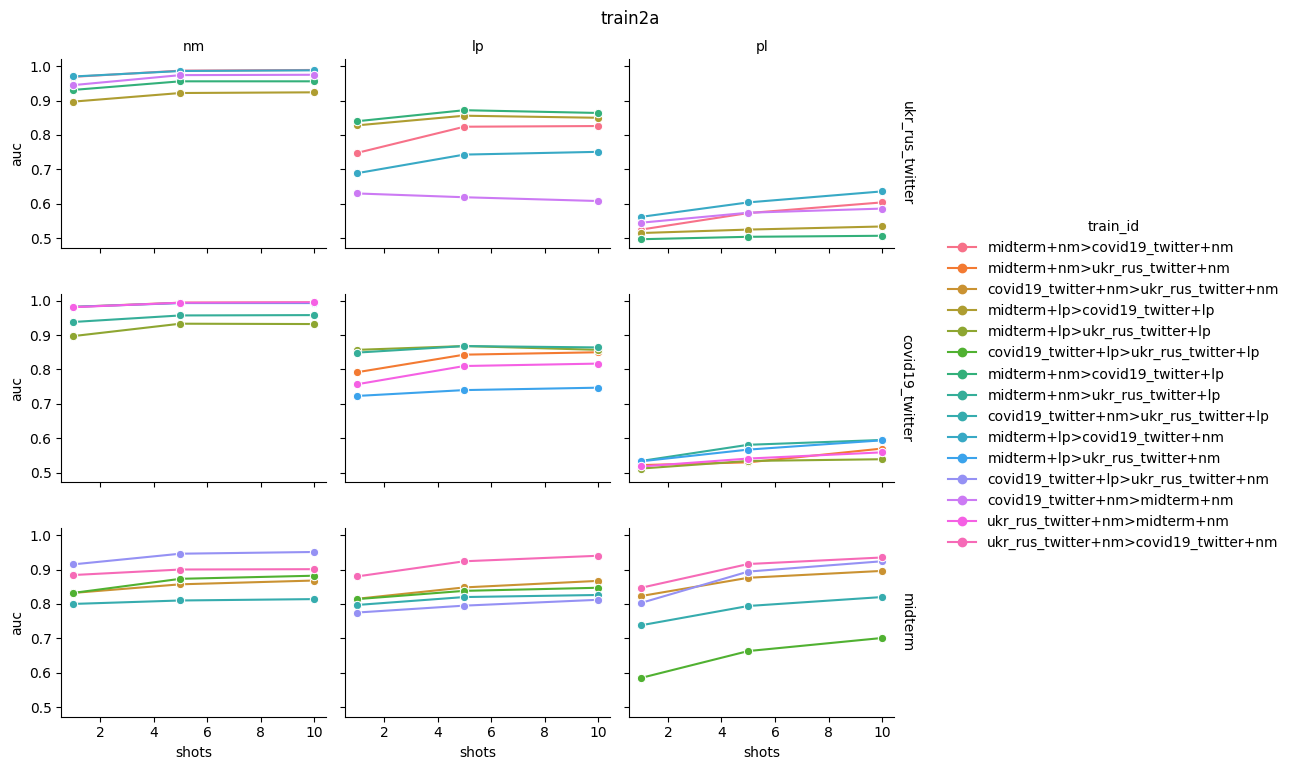

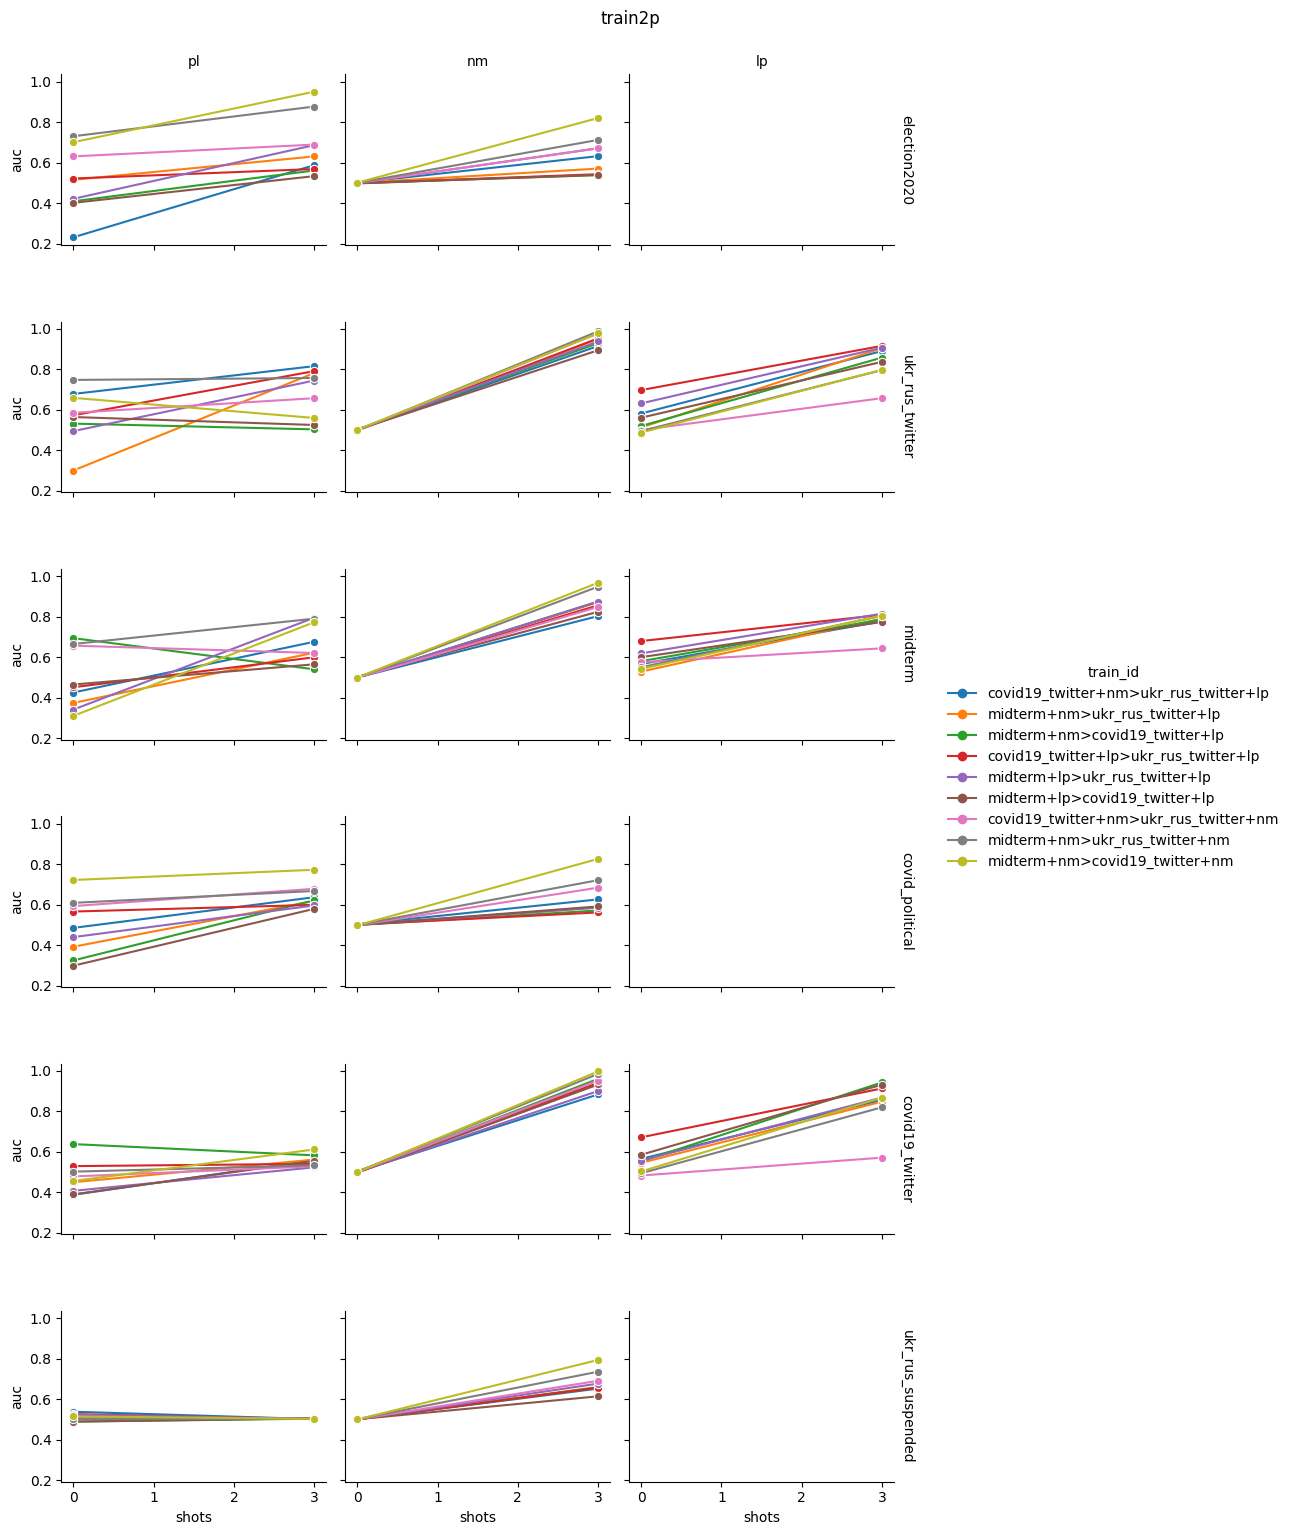

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grid(df, title):
    g = sns.relplot(
        data=df,
        x='shots', y='auc',
        hue='train_id',
        row='eval_dataset', col='eval_task',
        kind='line', marker='o',
        height=2.5, aspect=1.3,
        facet_kws={'sharey': True, 'margin_titles': True},
    )
    g.set_titles(row_template='{row_name}', col_template='{col_name}')
    g.fig.suptitle(title, y=1.02)
    return g

plot_grid(train2a, 'train2a')
plot_grid(train2p, 'train2p')
plt.show()

In [145]:
import plotly.express as px
import pandas as pd

combined = pd.concat([
    train2a.assign(source='train2a'),
    train2p.assign(source='train2p'),
], ignore_index=True)

fig = px.line(
    combined,
    x='shots', y='auc',
    color='train_id',
    symbol='source',
    symbol_map={'train2a': 'triangle-up', 'train2p': 'circle'},
    facet_row='eval_dataset',
    facet_col='eval_task',
    markers=True,
    height=900,  # bump up — lots of facets
)

# clean up the auto-generated facet labels ("eval_dataset=foo" → "foo")
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

# make markers bigger so triangles vs circles are obvious
fig.update_traces(marker=dict(size=10))

fig.update_layout(height=2000, width=2000)

fig.show()

<Axes: >

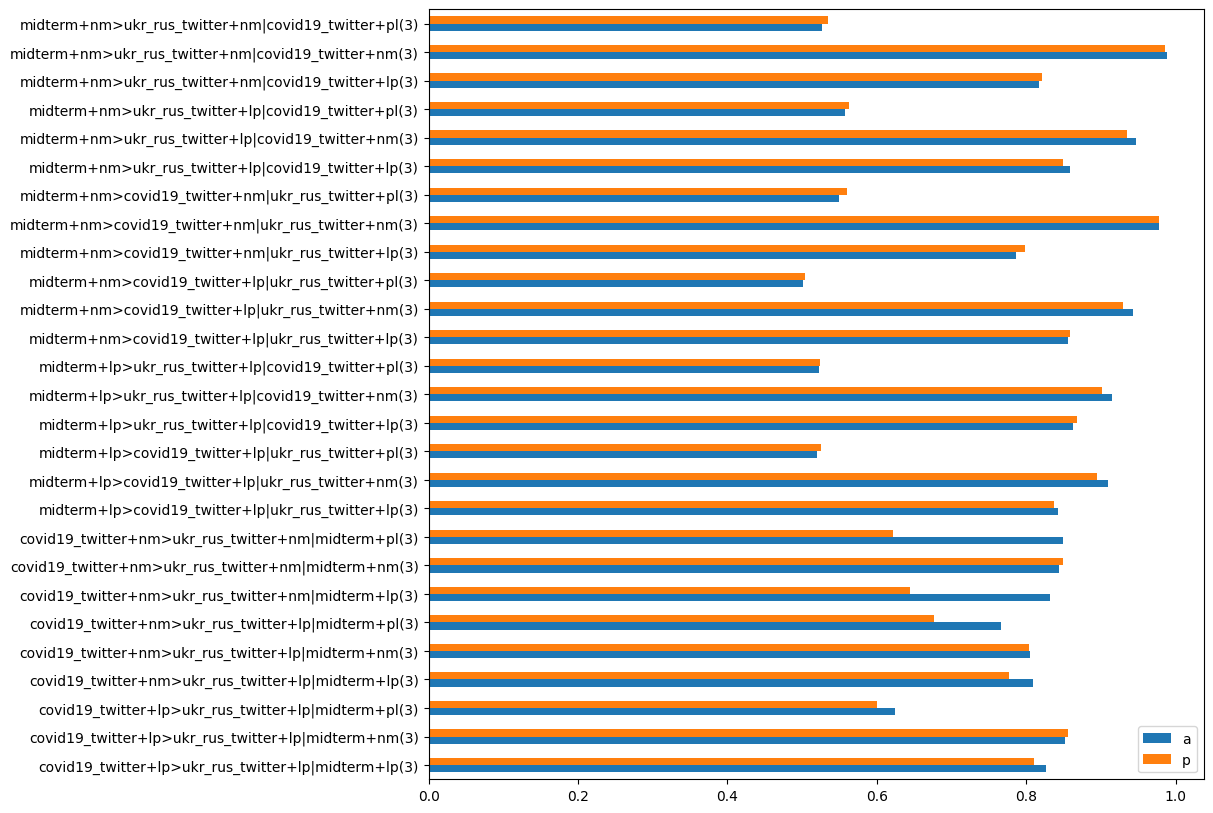

In [192]:
train2a['seq_'] = train2a[train2a.shots.isin([1,5])]['seq'].str.split("(").str[0]
train2p['seq_'] = train2p[train2p.shots.isin([1,5])]['seq'].str.split("(").str[0]
xx = train2a.groupby('seq_').auc.mean()
xx.index = xx.index + "(3)"
yy = train2p[train2p.shots.eq(3)].set_index('seq').auc
c = pd.DataFrame([xx,yy]).T
c.columns = ['a', 'p']
c = c.dropna()
c.plot.barh(figsize=(10,10))